In [82]:

#03_ModelTraining.ipynb

#Model  Development and Evaluation
import pandas as pd
import numpy as np

# Load feature  engineered  datasets
batsman_df  = pd.read_csv("batsman_model_dataset.csv", parse_dates=["date"])
bowler_df   = pd.read_csv("bowler_model_dataset.csv", parse_dates=["date"])

# Check shapes
print("Batsman dataset shape:", batsman_df.shape)
print("Bowler dataset shape :", bowler_df.shape)

# Check first few  rows
display(batsman_df.head(7))
display(bowler_df.head(7))


Batsman dataset shape: (15842, 21)
Bowler dataset shape : (12448, 19)


,match_id,date,venue,batting_team,bowling_team,batter,balls_faced,fours,sixes,strike_rate,...,runs_last_10,strike_rate_last_5,strike_rate_last_10,avg_runs_venue,avg_sr_venue,avg_runs_vs_team,avg_sr_vs_team,career_avg_runs,career_avg_sr,next_match_runs
0,548346,2012-04-29,Wankhede Stadium,Deccan Chargers,Mumbai Indians,A Ashish Reddy,10,0,1,100.000000,...,10.00,100.000000,100.000000,10.000000,100.000000,13.500000,106.666667,12.173913,135.390395,3.0
1,548352,2012-05-04,"MA Chidambaram Stadium, Chepauk",Deccan Chargers,Chennai Super Kings,A Ashish Reddy,3,0,0,100.000000,...,6.50,100.000000,100.000000,19.500000,162.500000,15.000000,141.666667,12.173913,135.390395,8.0
2,548359,2012-05-08,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Kings XI Punjab,A Ashish Reddy,8,1,0,100.000000,...,7.00,100.000000,100.000000,8.454545,119.776335,12.333333,158.333333,12.173913,135.390395,10.0
3,548373,2012-05-18,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,A Ashish Reddy,4,2,0,250.000000,...,7.75,137.500000,137.500000,8.454545,119.776335,12.333333,173.905724,12.173913,135.390395,4.0
4,548376,2012-05-20,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Royal Challengers Bangalore,A Ashish Reddy,5,0,0,80.000000,...,7.00,126.000000,126.000000,8.454545,119.776335,11.000000,103.222222,12.173913,135.390395,7.0
5,598000,2013-04-05,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Pune Warriors,A Ashish Reddy,4,1,0,175.000000,...,7.00,141.000000,134.166667,8.454545,119.776335,13.000000,150.833333,12.173913,135.390395,14.0
6,598004,2013-04-07,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,A Ashish Reddy,12,0,1,116.666667,...,8.00,144.333333,131.666667,8.454545,119.776335,11.000000,103.222222,12.173913,135.390395,3.0


,match_id,date,venue,batting_team,bowling_team,bowler,overs,economy,wickets_last_5,wickets_last_10,economy_last_5,economy_last_10,avg_wickets_venue,avg_economy_venue,avg_wickets_vs_team,avg_economy_vs_team,career_avg_wickets,career_avg_economy,next_match_wickets
0,548341,2012-04-26,Subrata Roy Sahara Stadium,Pune Warriors,Deccan Chargers,A Ashish Reddy,4.000000,8.000000,2.000000,2.000000,8.000000,8.000000,2.00,8.000000,1.333333,9.535088,0.95,9.37553,1.0
1,548346,2012-04-29,Wankhede Stadium,Mumbai Indians,Deccan Chargers,A Ashish Reddy,2.333333,4.714286,1.500000,1.500000,6.357143,6.357143,1.00,4.714286,1.000000,4.714286,0.95,9.37553,1.0
2,548348,2012-05-01,Barabati Stadium,Pune Warriors,Deccan Chargers,A Ashish Reddy,3.166667,10.105263,1.333333,1.333333,7.606516,7.606516,1.00,10.105263,1.333333,9.535088,0.95,9.37553,1.0
3,548352,2012-05-04,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Deccan Chargers,A Ashish Reddy,2.166667,7.384615,1.250000,1.250000,7.551041,7.551041,0.50,12.692308,1.000000,11.628205,0.95,9.37553,1.0
4,548356,2012-05-06,M Chinnaswamy Stadium,Royal Challengers Bangalore,Deccan Chargers,A Ashish Reddy,4.166667,8.640000,1.200000,1.200000,7.768833,7.768833,0.50,11.705455,1.000000,9.970303,0.95,9.37553,2.0
5,548359,2012-05-08,"Rajiv Gandhi International Stadium, Uppal",Kings XI Punjab,Deccan Chargers,A Ashish Reddy,4.166667,9.600000,1.200000,1.333333,8.088833,8.074027,1.25,9.075000,2.000000,9.600000,0.95,9.37553,0.0
6,548329,2012-05-10,"Rajiv Gandhi International Stadium, Uppal",Delhi Daredevils,Deccan Chargers,A Ashish Reddy,2.000000,14.500000,1.000000,1.142857,10.045976,8.992023,1.25,9.075000,0.500000,10.942308,0.95,9.37553,0.0


In [83]:
# BASELINE   MODEL
#   Batsman baseline
#  Predict  next  match runs = average of last 10  matches
batsman_df["baseline_pred_runs"] = batsman_df["runs_last_10"]

baseline_batsman_mae = (
    batsman_df["next_match_runs"] - batsman_df["baseline_pred_runs"]
).abs().mean()
print("Batsman Baseline MAE:", baseline_batsman_mae)
# Bowler baseline
# Predict next match wickets = average of last 10 matches
bowler_df["baseline_pred_wkts"] = bowler_df["wickets_last_10"]

baseline_bowler_mae = (
    bowler_df["next_match_wickets"] - bowler_df["baseline_pred_wkts"]
).abs().mean()

print("Bowler Baseline MAE:", baseline_bowler_mae)


Batsman Baseline MAE: 15.555368865763702
Bowler Baseline MAE: 0.8733017926000735


In [84]:

# TIME-BASED TRAIN AND TEST SPLIT


# Choose split date
split_date = "2021-01-01"

#Batsman split
batsman_train = batsman_df[batsman_df["date"] <= split_date]
batsman_test  = batsman_df[batsman_df["date"] > split_date]

# Bowler split
bowler_train = bowler_df[bowler_df["date"] <= split_date]
bowler_test  = bowler_df[bowler_df["date"] > split_date]

# Print shapes
print("Batsman train shape:", batsman_train.shape)
print("Batsman test shape :", batsman_test.shape)

print("Bowler train shape :", bowler_train.shape)
print("Bowler test shape  :", bowler_test.shape)

print("\nSplit date used:", split_date)


Batsman train shape: (11791, 22)
Batsman test shape : (4051, 22)
Bowler train shape : (9370, 20)
Bowler test shape  : (3078, 20)

Split date used: 2021-01-01


In [85]:
# SEPARATE FEATURES X AND TARGET y

# Batsman
target_batsman = "next_match_runs"

X_batsman_train = batsman_train.drop(
    columns=[target_batsman, "date", "match_id"]
)
y_batsman_train = batsman_train[target_batsman]

X_batsman_test = batsman_test.drop(
    columns=[target_batsman, "date", "match_id"]
)
y_batsman_test = batsman_test[target_batsman]

# Bowler
target_bowler = "next_match_wickets"

X_bowler_train = bowler_train.drop(
    columns=[target_bowler, "date", "match_id"]
)
y_bowler_train = bowler_train[target_bowler]

X_bowler_test = bowler_test.drop(
    columns=[target_bowler, "date", "match_id"]
)
y_bowler_test = bowler_test[target_bowler]

# Check shapes
print("X_batsman_train:", X_batsman_train.shape)
print("y_batsman_train:", y_batsman_train.shape)
print("X_batsman_test :", X_batsman_test.shape)
print("y_batsman_test :", y_batsman_test.shape)


X_batsman_train: (11791, 19)
y_batsman_train: (11791,)
X_batsman_test : (4051, 19)
y_batsman_test : (4051,)


In [86]:
# IDENTIFY CATEGORICAL & NUMERICAL COLUMNSS

#Batsman
cat_cols_batsman = ["venue", "batting_team", "bowling_team", "batter"]
num_cols_batsman = [col for col in X_batsman_train.columns if col not in cat_cols_batsman]

print("Batsman categorical columns:", cat_cols_batsman)
print("Batsman numerical columns:", num_cols_batsman)
print("Total batsman features:", len(cat_cols_batsman) + len(num_cols_batsman))

print("\n")

#Bowler
cat_cols_bowler = ["venue", "batting_team", "bowling_team", "bowler"]
num_cols_bowler = [col for col in X_bowler_train.columns if col not in cat_cols_bowler]

print("Bowler categorical columns:", cat_cols_bowler)
print("Bowler numerical columns:", num_cols_bowler)
print("Total bowler features:", len(cat_cols_bowler) + len(num_cols_bowler))


Batsman categorical columns: ['venue', 'batting_team', 'bowling_team', 'batter']
Batsman numerical columns: ['balls_faced', 'fours', 'sixes', 'strike_rate', 'runs_last_5', 'runs_last_10', 'strike_rate_last_5', 'strike_rate_last_10', 'avg_runs_venue', 'avg_sr_venue', 'avg_runs_vs_team', 'avg_sr_vs_team', 'career_avg_runs', 'career_avg_sr', 'baseline_pred_runs']
Total batsman features: 19


Bowler categorical columns: ['venue', 'batting_team', 'bowling_team', 'bowler']
Bowler numerical columns: ['overs', 'economy', 'wickets_last_5', 'wickets_last_10', 'economy_last_5', 'economy_last_10', 'avg_wickets_venue', 'avg_economy_venue', 'avg_wickets_vs_team', 'avg_economy_vs_team', 'career_avg_wickets', 'career_avg_economy', 'baseline_pred_wkts']
Total bowler features: 17


In [87]:
# PREPROCESSING PIPELINE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Batsman preprocessor
preprocessor_batsman = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_batsman),
        ("num", StandardScaler(), num_cols_batsman)
    ]
)

#Bowler preprocessor
preprocessor_bowler = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_bowler),
        ("num", StandardScaler(), num_cols_bowler)
    ]
)

print("Preprocessing pipelines created successfully")


Preprocessing pipelines created successfully


In [88]:

# RANDOM FOREST MODEL TRAININGG


from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

#Batsman Random Forest
rf_batsman = Pipeline(
    steps=[
        ("preprocessor", preprocessor_batsman),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

#Bowlerr Random Forest
rf_bowler = Pipeline(
    steps=[
        ("preprocessor", preprocessor_bowler),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train models
rf_batsman.fit(X_batsman_train, y_batsman_train)
rf_bowler.fit(X_bowler_train, y_bowler_train)

print("Random Forest models trained successfully")


Random Forest models trained successfully


In [89]:

# RANDOM FOREST EVALUATIONN


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#Batsman evaluation
batsman_preds_rf = rf_batsman.predict(X_batsman_test)

batsman_rmse_rf = np.sqrt(mean_squared_error(y_batsman_test, batsman_preds_rf))
batsman_mae_rf  = mean_absolute_error(y_batsman_test, batsman_preds_rf)
batsman_r2_rf   = r2_score(y_batsman_test, batsman_preds_rf)

print("Random Forest Batsman Performance:")
print("RMSE:", batsman_rmse_rf)
print("MAE :", batsman_mae_rf)
print("R2  :", batsman_r2_rf)

print("\n")

#Bowlerr evaluation
bowler_preds_rf = rf_bowler.predict(X_bowler_test)

bowler_rmse_rf = np.sqrt(mean_squared_error(y_bowler_test, bowler_preds_rf))
bowler_mae_rf  = mean_absolute_error(y_bowler_test, bowler_preds_rf)
bowler_r2_rf   = r2_score(y_bowler_test, bowler_preds_rf)

print("Random Forest Bowler Performance:")
print("RMSE:", bowler_rmse_rf)
print("MAE :", bowler_mae_rf)
print("R2  :", bowler_r2_rf)


Random Forest Batsman Performance:
RMSE: 20.775060891496647
MAE : 15.394830905949147
R2  : 0.13158281584869813


Random Forest Bowler Performance:
RMSE: 1.0539557504900516
MAE : 0.8250086636343947
R2  : 0.06062850461896585


In [90]:
# XGBOOST MODEL TRAINING  UNTUNED
from xgboost import XGBRegressor

#Batsman XGBoost 
xgb_batsman = Pipeline(
    steps=[
        ("preprocessor", preprocessor_batsman),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

#Bowler XGBoost
xgb_bowler = Pipeline(
    steps=[
        ("preprocessor", preprocessor_bowler),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train models
xgb_batsman.fit(X_batsman_train, y_batsman_train)
xgb_bowler.fit(X_bowler_train, y_bowler_train)

print("XGBoost models trained successfully")


XGBoost models trained successfully


In [91]:

# XGBOOST EVALUATION


#batsman evaluation
batsman_preds_xgb = xgb_batsman.predict(X_batsman_test)

batsman_rmse_xgb = np.sqrt(mean_squared_error(y_batsman_test, batsman_preds_xgb))
batsman_mae_xgb  = mean_absolute_error(y_batsman_test, batsman_preds_xgb)
batsman_r2_xgb   = r2_score(y_batsman_test, batsman_preds_xgb)

print("XGBoost Batsman Performance:")
print("RMSE:", batsman_rmse_xgb)
print("MAE :", batsman_mae_xgb)
print("R2  :", batsman_r2_xgb)

print("\n")

#bowler evaluation
bowler_preds_xgb = xgb_bowler.predict(X_bowler_test)

bowler_rmse_xgb = np.sqrt(mean_squared_error(y_bowler_test, bowler_preds_xgb))
bowler_mae_xgb  = mean_absolute_error(y_bowler_test, bowler_preds_xgb)
bowler_r2_xgb   = r2_score(y_bowler_test, bowler_preds_xgb)

print("XGBoost Bowler Performance:")
print("RMSE:", bowler_rmse_xgb)
print("MAE :", bowler_mae_xgb)
print("R2  :", bowler_r2_xgb)


XGBoost Batsman Performance:
RMSE: 20.894361008113073
MAE : 15.481357777318788
R2  : 0.1215804636791219


XGBoost Bowler Performance:
RMSE: 1.057402785697266
MAE : 0.8283302255647766
R2  : 0.054473897571224894


In [92]:

# OPTUNA TUNING FOR XGBOOST BATSMANN
import optuna
from sklearn.metrics import mean_absolute_error

def objective_batsman(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor_batsman),
            ("model", XGBRegressor(**params))
        ]
    )

    model.fit(X_batsman_train, y_batsman_train)
    preds = model.predict(X_batsman_test)

    return mean_absolute_error(y_batsman_test, preds)


study_batsman = optuna.create_study(direction="minimize")
study_batsman.optimize(objective_batsman, n_trials=30)

print("Best Batsman MAE:", study_batsman.best_value)
print("Best Batsman Params:", study_batsman.best_params)


[I 2026-01-08 12:30:28,321] A new study created in memory with name: no-name-9022153a-ef04-4a90-92bb-019102efd1cd
[I 2026-01-08 12:30:30,105] Trial 0 finished with value: 16.026180950699914 and parameters: {'n_estimators': 572, 'max_depth': 6, 'learning_rate': 0.1139135982745969, 'subsample': 0.9168536534900431, 'colsample_bytree': 0.7418177637210182, 'min_child_weight': 5}. Best is trial 0 with value: 16.026180950699914.
[I 2026-01-08 12:30:32,023] Trial 1 finished with value: 16.290064256916928 and parameters: {'n_estimators': 504, 'max_depth': 7, 'learning_rate': 0.17381005102460714, 'subsample': 0.7995513719517959, 'colsample_bytree': 0.6926228411182032, 'min_child_weight': 8}. Best is trial 0 with value: 16.026180950699914.
[I 2026-01-08 12:30:32,700] Trial 2 finished with value: 15.321172939939459 and parameters: {'n_estimators': 203, 'max_depth': 3, 'learning_rate': 0.0750837787483356, 'subsample': 0.9275051929009114, 'colsample_bytree': 0.9156921063747935, 'min_child_weight': 4

Best Batsman MAE: 15.221244681178714
Best Batsman Params: {'n_estimators': 317, 'max_depth': 5, 'learning_rate': 0.013061028181418542, 'subsample': 0.8274450771669508, 'colsample_bytree': 0.8742203475909704, 'min_child_weight': 6}


In [93]:
# FINAL TUNED XGBOOST bATSMAN
# Use best parameters from Optuna
best_batsman_params = study_batsman.best_params
best_batsman_params.update({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
})

#  Build final tuned model
xgb_batsman_tuned = Pipeline(
    steps=[
        ("preprocessor", preprocessor_batsman),
        ("model", XGBRegressor(**best_batsman_params))
    ]
)

#  Train model
xgb_batsman_tuned.fit(X_batsman_train, y_batsman_train)

#  Evaluate
batsman_preds_tuned = xgb_batsman_tuned.predict(X_batsman_test)

batsman_rmse_tuned = np.sqrt(mean_squared_error(y_batsman_test, batsman_preds_tuned))
batsman_mae_tuned  = mean_absolute_error(y_batsman_test, batsman_preds_tuned)
batsman_r2_tuned   = r2_score(y_batsman_test, batsman_preds_tuned)

print("Final Tuned XGBoost Batsman Performance:")
print("RMSE:", batsman_rmse_tuned)
print("MAE :", batsman_mae_tuned)
print("R2  :", batsman_r2_tuned)


Final Tuned XGBoost Batsman Performance:
RMSE: 20.449262358947802
MAE : 15.221244681178714
R2  : 0.15860661824728362


In [94]:
# XgBOOST FOR BOWLER UNTUNED 

# Build bowler XGBoost model
xgb_bowler_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_bowler),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train model
xgb_bowler_final.fit(X_bowler_train, y_bowler_train)

# Evaluate
bowler_preds_final = xgb_bowler_final.predict(X_bowler_test)

bowler_rmse_final = np.sqrt(mean_squared_error(y_bowler_test, bowler_preds_final))
bowler_mae_final  = mean_absolute_error(y_bowler_test, bowler_preds_final)
bowler_r2_final   = r2_score(y_bowler_test, bowler_preds_final)

print("Final XGBoost Bowler Performance:")
print("RMSE:", bowler_rmse_final)
print("MAE :", bowler_mae_final)
print("R2  :", bowler_r2_final)


Final XGBoost Bowler Performance:
RMSE: 1.0500580846245904
MAE : 0.8221679173536718
R2  : 0.06756349429830555


In [95]:

# LIGHTGBM MODEL TRAINING

from lightgbm import LGBMRegressor

#Batsman  LightGBM 
lgbm_batsman = Pipeline(
    steps=[
        ("preprocessor", preprocessor_batsman),
        ("model", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            random_state=42
        ))
    ]
)

lgbm_batsman.fit(X_batsman_train, y_batsman_train)

# Evaluate batsman
batsman_preds_lgbm = lgbm_batsman.predict(X_batsman_test)

batsman_rmse_lgbm = np.sqrt(mean_squared_error(y_batsman_test, batsman_preds_lgbm))
batsman_mae_lgbm  = mean_absolute_error(y_batsman_test, batsman_preds_lgbm)
batsman_r2_lgbm   = r2_score(y_batsman_test, batsman_preds_lgbm)

print("LightGBM Batsman Performance:")
print("RMSE:", batsman_rmse_lgbm)
print("MAE :", batsman_mae_lgbm)
print("R2  :", batsman_r2_lgbm)

print("\n")

#Bowler LightGBM 
lgbm_bowler = Pipeline(
    steps=[
        ("preprocessor", preprocessor_bowler),
        ("model", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            random_state=42
        ))
    ]
)

lgbm_bowler.fit(X_bowler_train, y_bowler_train)

# Evaluate bowler
bowler_preds_lgbm = lgbm_bowler.predict(X_bowler_test)

bowler_rmse_lgbm = np.sqrt(mean_squared_error(y_bowler_test, bowler_preds_lgbm))
bowler_mae_lgbm  = mean_absolute_error(y_bowler_test, bowler_preds_lgbm)
bowler_r2_lgbm   = r2_score(y_bowler_test, bowler_preds_lgbm)

print("LightGBM Bowler Performance:")
print("RMSE:", bowler_rmse_lgbm)
print("MAE :", bowler_mae_lgbm)
print("R2  :", bowler_r2_lgbm)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3546
[LightGBM] [Info] Number of data points in the train set: 11791, number of used features: 236
[LightGBM] [Info] Start training from score 20.094648


c:\Users\RAKESH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM Batsman Performance:
RMSE: 20.82125882833421
MAE : 15.429159150852499
R2  : 0.12771628672010515


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2669
[LightGBM] [Info] Number of data points in the train set: 9370, number of used features: 220
[LightGBM] [Info] Start training from score 0.990502
LightGBM Bowler Performance:
RMSE: 1.0574347001044524
MAE : 0.832463020956153
R2  : 0.05441682119346403


c:\Users\RAKESH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [96]:

# SHAP FEATURE IMPORTANCE BATSMAN


import shap

# Take a small sample for SHAP 
X_shap_sample = X_batsman_test.sample(300, random_state=42)

# Transform features using preprocessing pipeline
X_shap_transformed = preprocessor_batsman.transform(X_shap_sample)

# Extract trained XGBoost model
xgb_model_only = xgb_batsman_tuned.named_steps["model"]

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_only)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_transformed)

print("SHAP values computed successfully")


SHAP values computed successfully


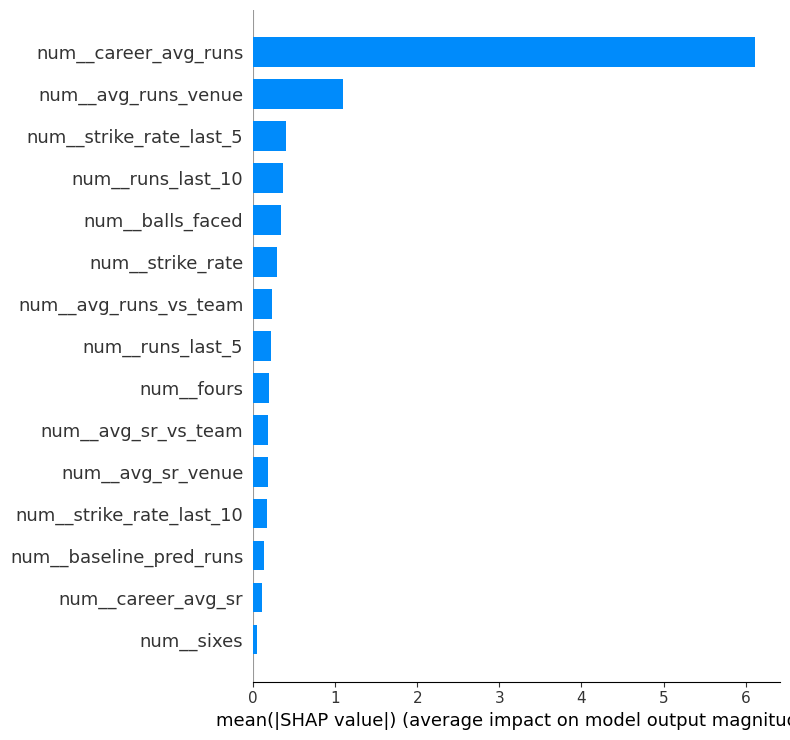

In [97]:

# SHAP SUMMARY PLOT (TOP FEATURES)
# Get feature names after preprocessing
feature_names = preprocessor_batsman.get_feature_names_out()

# Summary plot bar = global importance
shap.summary_plot(
    shap_values,
    features=X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)


In [98]:

# SHAP FEATURE IMPORTANCE BOWLER


import shap

# Take small sample for SHAP
X_shap_bowler = X_bowler_test.sample(300, random_state=42)

# Transform using bowler preprocessor
X_shap_bowler_transformed = preprocessor_bowler.transform(X_shap_bowler)

# Extract trained bowler XGBoost model
xgb_bowler_model_only = xgb_bowler_final.named_steps["model"]

# Create SHAP explainer
explainer_bowler = shap.TreeExplainer(xgb_bowler_model_only)

# Compute SHAP values
shap_values_bowler = explainer_bowler.shap_values(X_shap_bowler_transformed)

print("Bowler SHAP values computed successfully")


Bowler SHAP values computed successfully


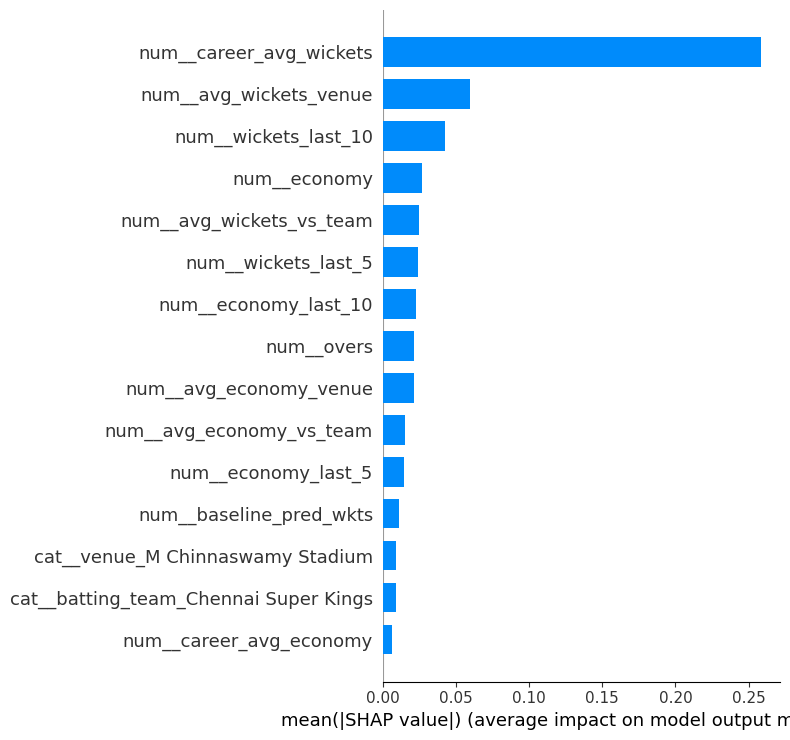

In [99]:

# SHAP SUMMARY PLOT BOWLER


# Get bowler feature names after preprocessing
bowler_feature_names = preprocessor_bowler.get_feature_names_out()

# Summary plot bar chart
shap.summary_plot(
    shap_values_bowler,
    features=X_shap_bowler_transformed,
    feature_names=bowler_feature_names,
    plot_type="bar",
    max_display=15
)


In [100]:

#SAVE FINAL MODELS & PIPELINES
import joblib

#BATSMAN
joblib.dump(xgb_batsman_tuned, "batsman_xgb_model.joblib")
joblib.dump(preprocessor_batsman, "batsman_feature_pipeline.pkl")

#BOWLER
joblib.dump(xgb_bowler_final, "bowler_xgb_model.joblib")
joblib.dump(preprocessor_bowler, "bowler_feature_pipeline.pkl")


print("- batsman_xgb_model.joblib")
print("- batsman_feature_pipeline.pkl")
print("- bowler_xgb_model.joblib")
print("- bowler_feature_pipeline.pkl")


- batsman_xgb_model.joblib
- batsman_feature_pipeline.pkl
- bowler_xgb_model.joblib
- bowler_feature_pipeline.pkl
